# Анализ коррелиции между инструментами

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
# Задаем тикеры (вместо MON-крипты взят общий базис; AAPL используется как основа для токенизированного аналога)
# Для криптовалют на Yahoo Finance используется суффикс -USD (например, XLM-USD)
tickers = ["XLM-USD", "XAUT-USD", "ADI", "AAPL"]

In [10]:
# Загружаем исторические данные за последний год
data = yf.download(tickers, period="5y")["Close"]

[*********************100%***********************]  4 of 4 completed


In [12]:
data

Ticker,AAPL,ADI,XAUT-USD,XLM-USD
Date,,,,
2021-09-04,NaN,NaN,1827.361694,0.370301
2021-09-05,NaN,NaN,1828.779053,0.397391
2021-09-06,NaN,NaN,1824.817627,0.423432
2021-09-07,152.830917,150.186768,1790.501221,0.334287
2021-09-08,151.289780,150.554672,1787.335815,0.329539
...,...,...,...,...
2026-08-31,316.850006,361.040009,4439.257812,0.177226
2026-09-01,325.130005,354.519989,4331.231934,0.175764
2026-09-02,324.959991,355.709991,4384.020508,0.175201


In [13]:
# Считаем процентные изменения цен (дневную доходность)
returns = data.pct_change().dropna()

# Вычисляем матрицу корреляции Пирсона
corr_matrix = returns.corr()

/mnt/e/wsl-cache/tmp/ipykernel_342799/3567941021.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


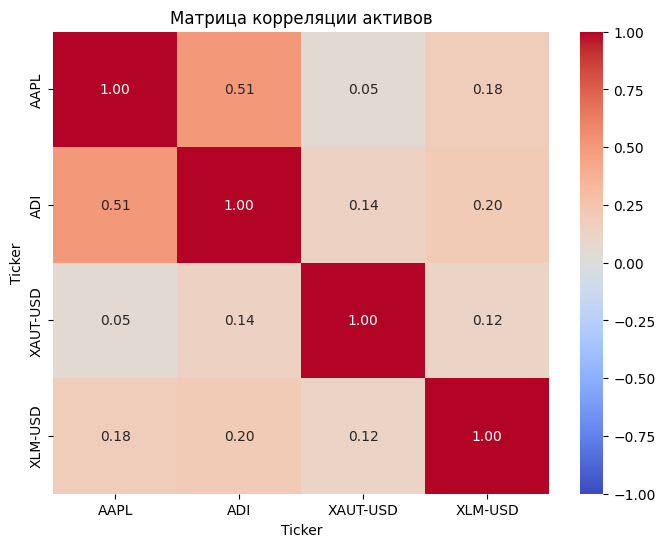

In [14]:
# Визуализируем тепловую карту
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Матрица корреляции активов")
plt.show()